In [1]:
import pandas as pd
from pymoo.indicators.hv import Hypervolume
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5, palette='pastel')

# FairRF vs Algorithm Variants

In [2]:
def read_results(file_path, strategy):
    meg_ris = pd.DataFrame()
    for file in os.listdir(file_path):
        data = file.split("_")[0]
        attr = file.split("_")[1]
        df = pd.read_csv(f"{file_path}/{file}", index_col=0)
        df["data"] = data
        df["attr"] = attr
        meg_ris = pd.concat([meg_ris, df])
        meg_ris["strategy"] = strategy
    return meg_ris


In [ ]:
cart = read_results("results_cart", 'FairCART')
knn = read_results("results_knn", 'FairKNN')
svm = read_results("results_svm", 'FairSVM')
lr = read_results("results_lr", 'FairLR')
rf = read_results("results_rf", 'FairRF')

In [ ]:
full_data = pd.concat([cart, knn, svm, lr, rf])
bin_data = full_data[full_data['data'].isin(['adult', 'bank', 'compas', 'german', 'mep'])]

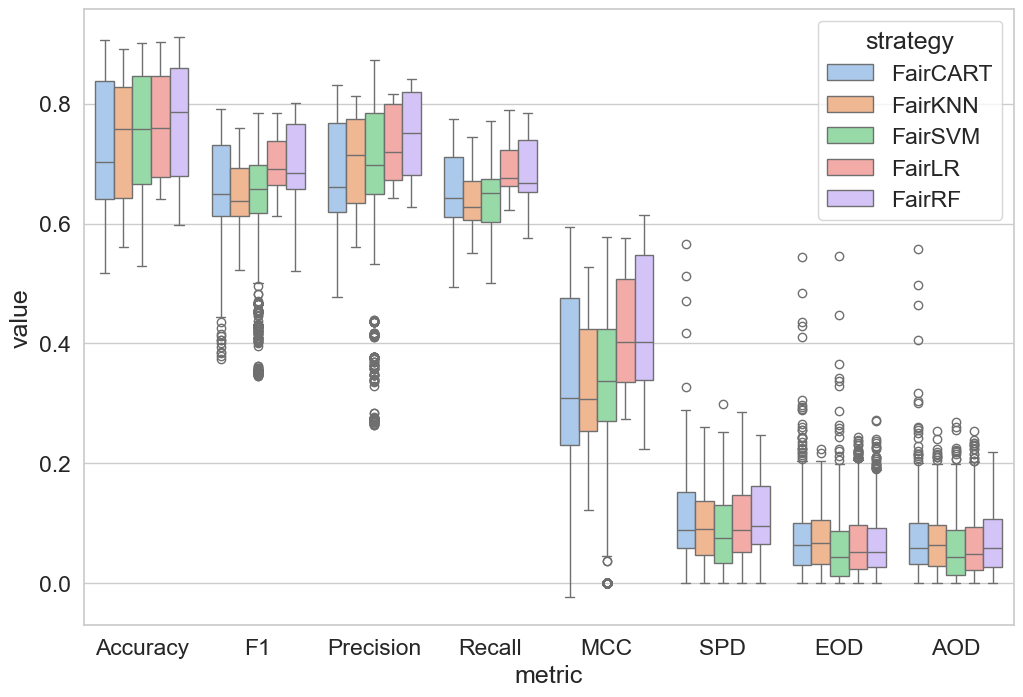

In [5]:
plot_data = bin_data
plot_data = pd.melt(plot_data, id_vars=['strategy', 'data', 'attr', 'Run'], value_vars=['Accuracy', 'F1', 'Precision', 'Recall', 'MCC', 'SPD', 'EOD', 'AOD'], var_name='metric', value_name='value')
plt.figure(figsize=(12, 8))
ax = sns.boxplot(x='metric', y='value', hue='strategy', data=plot_data)
plt.show()


## Hypervolume Score

In [6]:
bin_data['Accuracy'] = 1 - bin_data['Accuracy']
bin_data['F1'] = 1 - bin_data['F1']
bin_data['Precision'] = 1 - bin_data['Precision']
bin_data['Recall'] = 1 - bin_data['Recall']
bin_data['MCC'] = 1 - bin_data['MCC']

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_66938/3003211728.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data['Accuracy'] = 1 - bin_data['Accuracy']
/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_66938/3003211728.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data['F1'] = 1 - bin_data['F1']
/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_66938/3003211728.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [30]:
ref_point = np.array([max(bin_data[c]) + 0.5 for c in ['Accuracy', 'F1', 'Precision', 'Recall', 'MCC', 'SPD', 'EOD', 'AOD']])

In [31]:
ref_point

array([0.982, 1.154, 1.236, 1.006, 1.524, 1.066, 1.046, 1.057])

In [32]:
hv = Hypervolume(ref_point=ref_point)

In [7]:
ref_points = pd.DataFrame()
for data in bin_data['data'].unique():
    for attr in bin_data['attr'].unique():
        data_attr = bin_data[(bin_data['data'] == data) & (bin_data['attr'] == attr)]
        if not data_attr.empty:
            ref_point = np.array([max(data_attr[c]) + 0.5 for c in ['Accuracy', 'F1', 'Precision', 'Recall', 'MCC', 'SPD', 'EOD', 'AOD']])
            ref_points = pd.concat([ref_points, pd.DataFrame({'data': [data], 'attr': [attr], 'ref_point': [ref_point]})], ignore_index=True)

In [34]:
ref_points

,data,attr,ref_point
0,adult,race,"[0.806, 1.073, 1.127, 1.0, 1.5, 0.635, 0.78699..."
1,adult,sex,"[0.783, 1.073, 1.127, 1.0, 1.5, 0.827, 1.046, ..."
2,compas,race,"[0.971, 1.154, 1.236, 1.0, 1.5, 1.065999999999..."
3,compas,sex,"[0.982, 1.154, 1.236, 1.006, 1.524, 0.78299999..."
4,german,sex,"[0.937, 1.0979999999999999, 1.163, 1.0, 1.5, 0..."
5,german,age,"[0.91, 1.104, 1.172, 1.0, 1.5, 0.7989999999999..."
6,mep,RACE,"[0.73, 1.049, 1.089, 1.0, 1.5, 0.623, 0.718, 0..."
7,bank,age,"[0.631, 1.035, 1.065, 1.0, 1.5, 0.779, 0.772, ..."


In [ ]:
scores = pd.DataFrame()
for strategy in bin_data['strategy'].unique():
  for data in bin_data['data'].unique():
    for attr in bin_data['attr'].unique():
      for round in bin_data['Run'].unique():
        round_data = bin_data[(bin_data['strategy'] == strategy) & (bin_data['data'] == data) & (bin_data['attr'] == attr) & (bin_data['Run'] == round)]
        if not round_data.empty:
          ref_point = ref_points[(ref_points['data'] == data) & (ref_points['attr'] == attr)]['ref_point'].values[0]
          hv = Hypervolume(ref_point=ref_point)
          hv_score = hv(round_data[['Accuracy', 'F1', 'Precision', 'Recall', 'MCC', 'SPD', 'EOD', 'AOD']].values)
          scores = pd.concat(
            [scores, pd.DataFrame({'strategy': strategy, 'data': data, 'attr': attr, 'round': round, 'hv_score': hv_score}, index=[0])], 
            ignore_index=True)
      

In [10]:
scores

,strategy,data,attr,round,hv_score
0,FairCART,adult,race,18,0.110429
1,FairCART,adult,race,19,0.113888
2,FairCART,adult,race,6,0.118539
3,FairCART,adult,race,7,0.118331
4,FairCART,adult,race,5,0.122567
...,...,...,...,...,...
787,FairRF,bank,age,15,0.063715
788,FairRF,bank,age,11,0.064848
789,FairRF,bank,age,10,0.078718
790,FairRF,bank,age,12,0.085664


In [9]:
grouped = scores.groupby(['strategy', 'data', 'attr'])['hv_score'].agg(['mean', 'std']).reset_index()

In [10]:
groupedp = grouped.pivot(index=['data', 'attr'], columns='strategy', values=['mean', 'std']).round(3)

In [11]:
groupedp['FairCART'] = groupedp['mean']['FairCART'].astype(str) + " $\pm$ " + groupedp['std']['FairCART'].astype(str)
groupedp['FairKNN'] = groupedp['mean']['FairKNN'].astype(str) + " $\pm$ " + groupedp['std']['FairKNN'].astype(str)
groupedp['FairLR'] = groupedp['mean']['FairLR'].astype(str) + " $\pm$ " + groupedp['std']['FairLR'].astype(str)
groupedp['FairSVM'] = groupedp['mean']['FairSVM'].astype(str) + " $\pm$ " + groupedp['std']['FairSVM'].astype(str)
groupedp['FairRF'] = groupedp['mean']['FairRF'].astype(str) + " $\pm$ " + groupedp['std']['FairRF'].astype(str)

In [12]:
groupedp.drop(columns=['mean', 'std'], level=0).to_latex('hypervolumes.tex', escape=False)

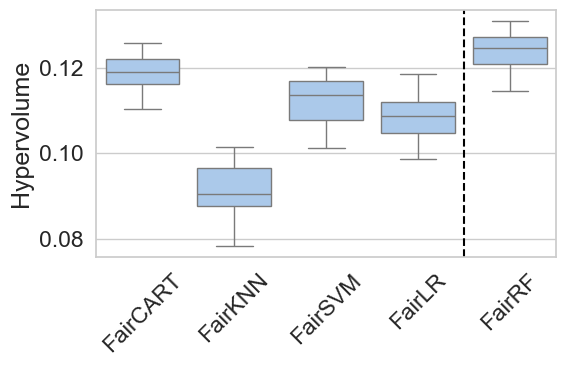

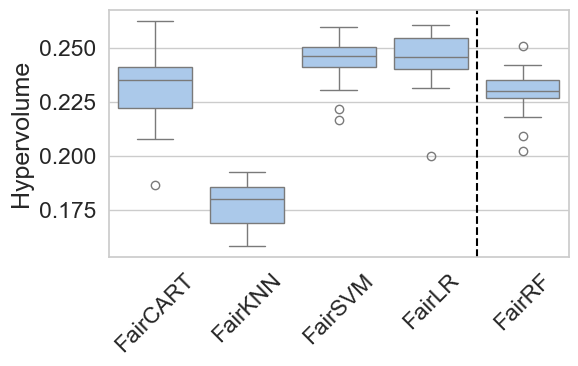

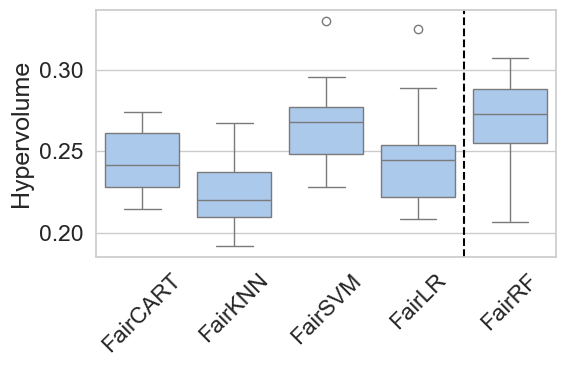

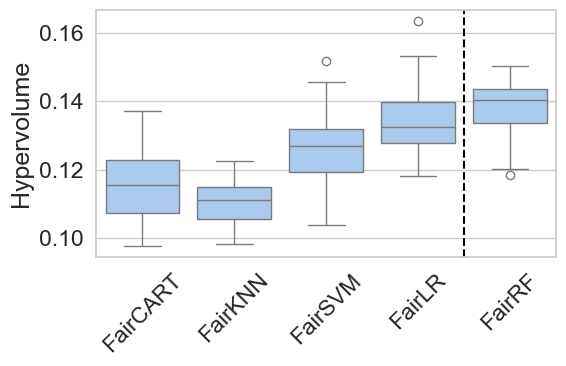

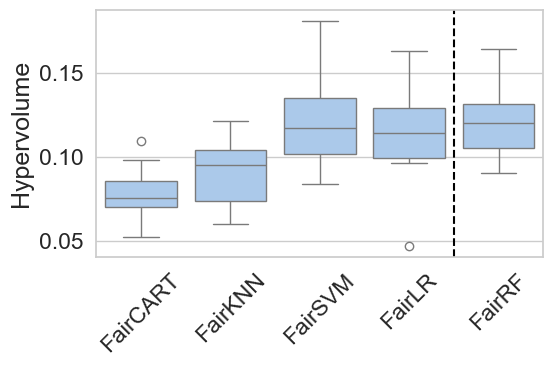

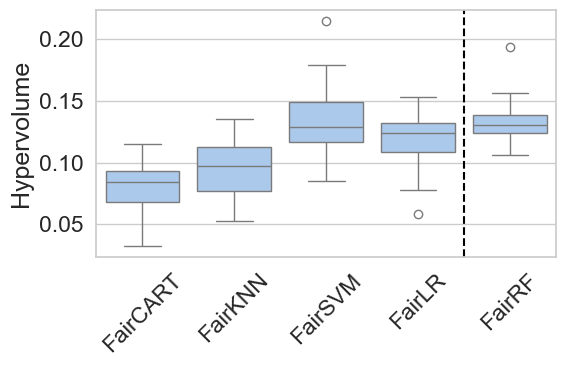

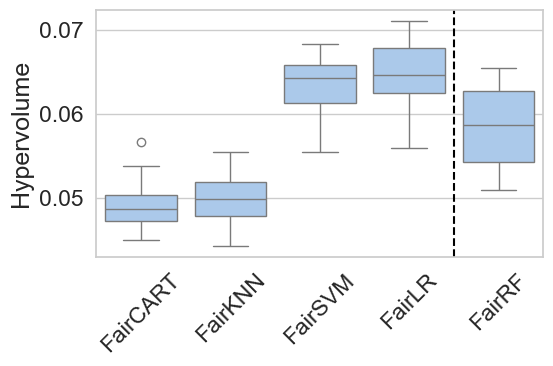

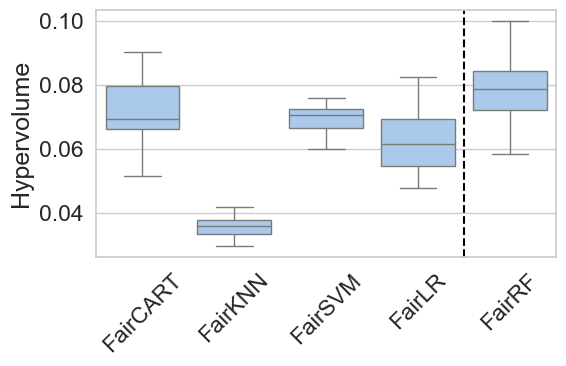

In [11]:
for data, attr in scores[['data', 'attr']].drop_duplicates().values:
  data_attr_data = scores[(scores['data'] == data) & (scores['attr'] == attr)]
  plt.figure(figsize=(6, 4))
  ax = sns.boxplot(x='strategy', y='hv_score', data=data_attr_data)
  ax.axvline(x=3.5, color='black', linestyle='--')
  # ax.set_title(f'Hypervolume Scores for {data} dataset with {attr} attribute')
  ax.set_ylabel('Hypervolume')
  ax.set_xlabel('')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.savefig(f'imgs/hv_{data}_{attr}.pdf', bbox_inches='tight')
  plt.show()

In [14]:
for strategy in scores['strategy'].unique():
  if strategy != 'FairRF' and strategy != 'FairSVM':
    for data in scores['data'].unique():
      for attr in scores['attr'].unique():
        fairrf_scores = scores[(scores['strategy'] == 'FairRF') & (scores['data'] == data) & (scores['attr'] == attr)]['hv_score']
        other_scores = scores[(scores['strategy'] == strategy) & (scores['data'] == data) & (scores['attr'] == attr)]['hv_score']
        if not fairrf_scores.empty and not other_scores.empty:
          from scipy.stats import wilcoxon
          stat, p = wilcoxon(fairrf_scores, other_scores, alternative='greater')
          print(f'Wilcoxon test between FairRF and {strategy} on {data} dataset with {attr} attribute: statistic={stat}, p-value={p}')

Wilcoxon test between FairRF and FairCART on adult dataset with race attribute: statistic=205.0, p-value=9.5367431640625e-06
Wilcoxon test between FairRF and FairCART on adult dataset with sex attribute: statistic=95.0, p-value=0.649409294128418
Wilcoxon test between FairRF and FairCART on compas dataset with race attribute: statistic=196.0, p-value=0.0001049041748046875
Wilcoxon test between FairRF and FairCART on compas dataset with sex attribute: statistic=210.0, p-value=9.5367431640625e-07
Wilcoxon test between FairRF and FairCART on german dataset with sex attribute: statistic=210.0, p-value=9.5367431640625e-07
Wilcoxon test between FairRF and FairCART on german dataset with age attribute: statistic=210.0, p-value=9.5367431640625e-07
Wilcoxon test between FairRF and FairCART on mep dataset with RACE attribute: statistic=209.0, p-value=1.9073486328125e-06
Wilcoxon test between FairRF and FairCART on bank dataset with age attribute: statistic=157.0, p-value=0.026584625244140625
Wilc